# Seq2Seq: Generowanie Tekstu na Podstawie Polskiej Literatury
### Kurs: Języki Naturalne w SI &nbsp;|&nbsp; Keras / TensorFlow

---

## Co to jest model Seq2Seq?

**Sekwencja-do-sekwencji** (ang. *sequence-to-sequence*, seq2seq) to architektura sieci neuronowej
zaprojektowana do przekształcania jednej sekwencji w drugą. Pierwotnie opracowana do **tłumaczenia
maszynowego** (Sutskever et al., 2014), dziś stosowana jest w:
- generowaniu tekstu i streszczaniu,
- systemach dialogowych (chatboty),
- rozpoznawaniu i syntezie mowy,
- odpowiadaniu na pytania.

Model składa się z dwóch bloków LSTM:

| Blok | Rola |
|------|------|
| **Enkoder** (*encoder*) | Czyta sekwencję wejściową i kompresuje ją do **wektora kontekstu** `[h, c]` |
| **Dekoder** (*decoder*) | Przyjmuje wektor kontekstu i generuje sekwencję wyjściową **znak po znaku** |

```
╔══════════════════════════════════════════════════════════════════════╗
║                    TRENING  (Teacher Forcing)                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Wejście enkodera:  [L][i][t][w][o][!][ ][O][j][c][z][y]...         ║
║                          │ LSTM Enkoder │                            ║
║                          └──── [h, c] ──┐  ← wektor kontekstu       ║
║                                         │                            ║
║  Wejście dekodera:  [►][s][ ][z][d][r][o][w][i][e]...               ║
║  (► = token START)       │ LSTM Dekoder │                            ║
║  Cel dekodera:      [ ][s][ ][z][d][r][o][w][i][e][.]...            ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════════════╗
║                    INFERENCJA  (krok po kroku)                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Enkoder czyta prompt → [h, c]                                       ║
║  Krok 1:  [►]      → LSTM Dekoder → predykcja znaku 1, [h1, c1]     ║
║  Krok 2:  [znak 1] → LSTM Dekoder → predykcja znaku 2, [h2, c2]     ║
║  ...      aż do osiągnięcia max długości                             ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
```

## Dane

Korpus: **7 083 utworów** z serwisu [Wolne Lektury](https://wolnelektury.pl) (polska literatura,
licencja domeny publicznej). W tym przykładzie używamy epoki **Romantyzm** (~1 024 teksty).

In [ ]:
# ============================================================
# KOMÓRKA 1: Instalacja zależności i importy
# ============================================================
# Uruchom tę komórkę jako pierwszą — zainstaluje potrzebne pakiety
# jeśli jeszcze nie są dostępne w środowisku.

import subprocess, sys

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "tensorflow", "keras", "numpy", "matplotlib"],
    check=True
)

# --- Standardowe importy ---
import os
import glob
import re
import unicodedata
import time
import random
import gc
import resource

import numpy as np
import matplotlib.pyplot as plt

# --- Obsługa GPU (musi być PRZED import tensorflow) ---
# TensorFlow wymaga pliku libdevice.10.bc do kompilacji JIT na GPU.
# Szukamy go w typowych lokalizacjach; jeśli znajdziemy — ustawiamy
# XLA_FLAGS żeby TF wiedział gdzie patrzeć.
# Jeśli nie znajdziemy — wyłączamy GPU przez CUDA_VISIBLE_DEVICES.

_libdevice_candidates = [
    # Lokalny katalog projektu (np. ./cuda/nvvm/libdevice/)
    os.path.join(os.path.dirname(os.path.abspath('.')),
                 'Sec_2_sec', 'cuda', 'nvvm', 'libdevice', 'libdevice.10.bc'),
    os.path.join(os.getcwd(), 'cuda', 'nvvm', 'libdevice', 'libdevice.10.bc'),
    # Systemowe instalacje CUDA
    '/usr/local/cuda/nvvm/libdevice/libdevice.10.bc',
    '/opt/cuda/nvvm/libdevice/libdevice.10.bc',
]
# Dodaj pliki z pakietów nvidia zainstalowanych przez pip
_libdevice_candidates += glob.glob(
    os.path.join(sys.prefix, 'lib', 'python*', 'site-packages',
                 'nvidia', '*', 'nvvm', 'libdevice', 'libdevice.10.bc')
)

_libdevice_path = next((p for p in _libdevice_candidates if os.path.exists(p)), None)

if _libdevice_path:
    # xla_gpu_cuda_data_dir to katalog nadrzędny względem nvvm/
    _cuda_data_dir = os.path.dirname(os.path.dirname(os.path.dirname(_libdevice_path)))
    os.environ['XLA_FLAGS'] = f'--xla_gpu_cuda_data_dir={_cuda_data_dir}'
    print(f"libdevice znaleziony: {_libdevice_path}")
    print(f"XLA_FLAGS ustawione → {_cuda_data_dir}")
else:
    # Brak libdevice — wyłączamy GPU przed importem TF
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
    print("libdevice.10.bc nie znaleziony — trening na CPU.")
    print("Aby włączyć GPU: umieść plik w ./cuda/nvvm/libdevice/libdevice.10.bc")

import tensorflow as tf
import keras
from keras.layers import LSTM, Dense, Input
from keras.models import Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- Ziarno losowości — dla powtarzalności wyników ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# --- Informacje o środowisku ---
gpus = tf.config.list_physical_devices('GPU')

# Dynamiczny przydział VRAM — bez tego TF od razu rezerwuje całe GPU,
# a po kilku epokach przy dłuższym treningu (>6) system zaczyna swapować
# i potrafi się zawiesić. set_memory_growth pozwala TF rosnąć stopniowo.
for _gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except RuntimeError as _e:
        # Już zainicjalizowane — w Jupyter zdarza się przy ponownym uruchomieniu
        print(f"  set_memory_growth: {_e}")

print(f"\nPython:     {sys.version.split()[0]}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {keras.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"GPU:        {gpus[0].name if gpus else 'brak (CPU)'}")


# --- Sprawdzenie urządzenia tuż przed treningiem ---
# KOMÓRKA 1 ustawia GPU/CPU globalnie; tu tylko potwierdzamy stan,
# żeby nie zmarnować godzin na nieświadomy trening po CPU.
_gpus = tf.config.list_physical_devices('GPU')
if _gpus:
    _detale = tf.config.experimental.get_device_details(_gpus[0])
    _nazwa = _detale.get('device_name', _gpus[0].name)
    print(f"  Urządzenie:  GPU — {_nazwa}")
else:
    print(f"  Urządzenie:  CPU (brak widocznego GPU — trening będzie znacznie wolniejszy)")
print()

---
## 1. Wczytywanie i czyszczenie korpusu

Pliki z Wolnych Lektur mają ustandaryzowany format:

```
Adam Mickiewicz

Pan Tadeusz

ISBN 978-83-...

Litwo! Ojczyzno moja!...  ← właściwy tekst
-----
Ta lektura, podobnie jak...  ← metadane licencyjne — pomijamy
```

**Kroki czyszczenia:**
1. Odcinamy stopkę po separatorze `-----`
2. Pomijamy nagłówek (autor, tytuł, ISBN)
3. Zachowujemy tylko litery (w tym polskie ą ę ó ś ź ż ć ń ł), cyfry, interpunkcję, spacje i nowe linie
4. Normalizujemy wielokrotne spacje i puste wiersze

In [15]:
# ============================================================
# KOMÓRKA 2: Wczytywanie i czyszczenie korpusu
# ============================================================

# Katalog z książkami posortowanymi według epoki
CORPUS_DIR = './WOLNE_LEKTURY_SCRAPING/books'


def wczytaj_i_oczyszcz_plik(sciezka: str) -> str:
    """
    Wczytuje jeden plik Wolnych Lektur i zwraca oczyszczony tekst.
    """
    with open(sciezka, encoding='utf-8') as f:
        zawartosc = f.read()

    # Krok 1: odetnij stopkę licencyjną (wszystko po pierwszym '-----')
    tekst = zawartosc.split('-----')[0]

    # Krok 2: pomiń nagłówek (autor + tytuł + opcjonalnie ISBN)
    linie = tekst.split('\n')
    linia_isbn = next(
        (i for i, l in enumerate(linie[:20]) if l.strip().startswith('ISBN')),
        -1
    )

    if linia_isbn >= 0:
        # Jest ISBN — treść zaczyna się po ISBN i pustych wierszach
        i = linia_isbn + 1
        while i < len(linie) and not linie[i].strip():
            i += 1
        poczatek = i
    else:
        # Bez ISBN — pomiń pierwsze 2 niepuste wiersze (autor + tytuł)
        licznik, i = 0, 0
        while i < len(linie) and licznik < 2:
            if linie[i].strip():
                licznik += 1
            i += 1
        while i < len(linie) and not linie[i].strip():
            i += 1
        poczatek = i

    tekst = '\n'.join(linie[poczatek:]).strip()

    # Krok 3: zachowaj tylko dozwolone znaki
    # unicodedata.category zwraca kategorię znaku Unicode:
    #   'L' = litery (w tym polskie diakrytyki),
    #   'N' = cyfry,
    #   'P' = interpunkcja
    dozwolone = []
    for znak in tekst:
        if znak in (' ', '\n'):
            dozwolone.append(znak)
        elif unicodedata.category(znak)[0] in ('L', 'N', 'P'):
            dozwolone.append(znak)
        # Pomijamy: miękkie łączniki (\xad), cudzysłowy typograficzne,
        # znaki kontrolne i inne śmieci

    tekst = ''.join(dozwolone)

    # Krok 4: znormalizuj białe znaki
    tekst = re.sub(r' {2,}', ' ', tekst)       # wiele spacji → jedna
    tekst = re.sub(r'\n{3,}', '\n\n', tekst)   # wiele pustych wierszy → dwa

    return tekst.strip()


def wczytaj_korpus(katalogi: list, min_dlug: int = 300) -> str:
    """
    Łączy teksty ze wskazanych podkatalogów epok w jeden ciąg.
    Pomija pliki krótsze niż min_dlug znaków.
    """
    wszystkie = []
    liczba_plikow = 0

    for katalog in katalogi:
        sciezka_katalogu = os.path.join(CORPUS_DIR, katalog)
        pliki = sorted(glob.glob(os.path.join(sciezka_katalogu, '*.txt')))

        for sciezka in pliki:
            try:
                tekst = wczytaj_i_oczyszcz_plik(sciezka)
                if len(tekst) >= min_dlug:
                    wszystkie.append(tekst)
                    liczba_plikow += 1
            except Exception:
                pass  # pomiń uszkodzone pliki bez przerywania pracy

    pelny_tekst = '\n\n'.join(wszystkie)
    print(f"Wczytano {liczba_plikow} plików z epok: {katalogi}")
    print(f"Łączna długość korpusu: {len(pelny_tekst):,} znaków")
    return pelny_tekst


# Zawężamy korpus do samego Romantyzmu — stylistyczna spójność z promptem
# z "Pana Tadeusza", brak obcych nazw własnych (np. "Atos", "d'Artagnan"
# z polskiego tłumaczenia "Trzech muszkieterów") mieszających styl modelu.
EPOKI = ['Romantyzm']
pelny_tekst = wczytaj_korpus(EPOKI)

print(f"\nFragment korpusu (pierwsze 300 znaków):")
print('-' * 60)
print(pelny_tekst[:300])
print('-' * 60)


Wczytano 985 plików z epok: ['Romantyzm']
Łączna długość korpusu: 41,061,678 znaków

Fragment korpusu (pierwsze 300 znaków):
------------------------------------------------------------
A jednak ja nie wątpię — bo się pora zbliża,
Że się to wielkie światło na niebie zapali,
I Polski Ty, o Boże, nie odepniesz z krzyża,
Aż będziesz wiedział, że się jako trup nie zwali.

Dzięki Ci więc, o Boże — że już byłeś blisko,
A jeszcześ Twojej złotej nie odsłonił twarzy,
Aleś nas, syny Twoje, d
------------------------------------------------------------


---
## 2. Budowanie słownika znaków

W modelu **znakowym** (*character-level*) każdy pojedynczy znak jest osobnym tokenem.
Zaletą tego podejścia jest brak potrzeby tokenizatora i naturalna obsługa fleksji polskiej
(odmiana przez przypadki, koniugacja). Wadą jest to, że model musi "nauczyć się" budować
słowa od zera.

Dodajemy dwa specjalne tokeny:

| Token | Symbol | Rola |
|-------|--------|------|
| START | `\t` (TAB) | Sygnał początku sekwencji dekodera — nie występuje w tekstach literackich |
| STOP  | `\n` (newline) | Sygnał końca generacji — naturalny w tekście |

Każdy znak jest reprezentowany jako **wektor one-hot**: wektor zer z jedynką
na pozycji odpowiadającej danemu znakowi w słowniku.

Rozmiar słownika: 270 unikalnych znaków
  Znaki ASCII (< 128):          83
  Polskie diakrytyki (U+0100+): 150

Indeks ZNAK_START (TAB): 0
Indeks ZNAK_STOP  (\n):  1


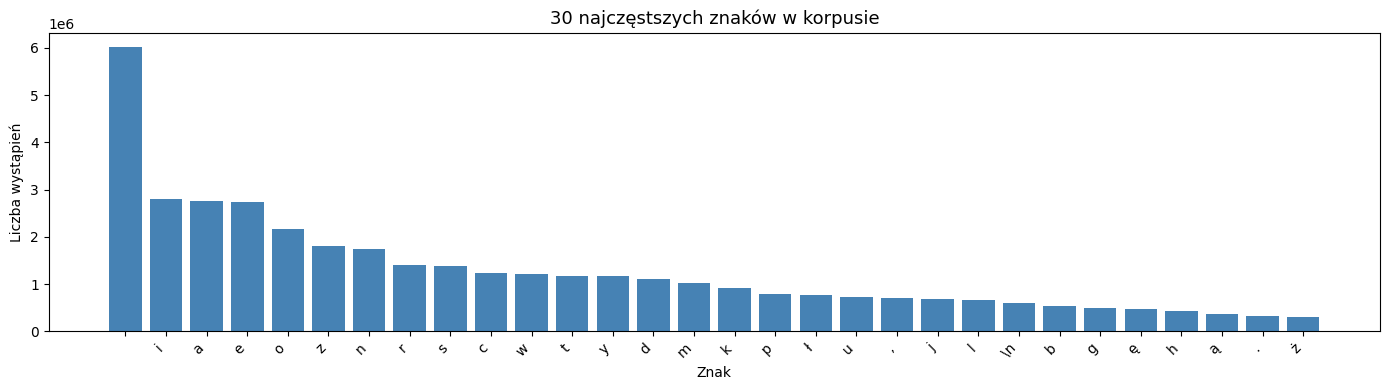

In [16]:
# ============================================================
# KOMÓRKA 3: Budowanie słownika znaków
# ============================================================

ZNAK_START = '\t'   # token początku — gwarantujemy, że nie ma go w tekstach
ZNAK_STOP  = '\n'   # token końca — naturalny koniec wiersza

# Zbieramy wszystkie unikalne znaki + token START, sortujemy dla powtarzalności
wszystkie_znaki = sorted(set(pelny_tekst) | {ZNAK_START})

# Słowniki: znak <-> indeks liczbowy
znak_na_idx = {z: i for i, z in enumerate(wszystkie_znaki)}
idx_na_znak = {i: z for z, i in znak_na_idx.items()}

ROZMIAR_SLOWNIKA = len(wszystkie_znaki)

print(f"Rozmiar słownika: {ROZMIAR_SLOWNIKA} unikalnych znaków")
print(f"  Znaki ASCII (< 128):          {sum(1 for z in wszystkie_znaki if ord(z) < 128)}")
print(f"  Polskie diakrytyki (U+0100+): {sum(1 for z in wszystkie_znaki if ord(z) >= 0x100)}")
print(f"\nIndeks ZNAK_START (TAB): {znak_na_idx[ZNAK_START]}")
print(f"Indeks ZNAK_STOP  (\\n):  {znak_na_idx[ZNAK_STOP]}")

# --- Wizualizacja częstości znaków ---
czestosci = {z: pelny_tekst.count(z) for z in wszystkie_znaki if z != ZNAK_START}
top30 = sorted(czestosci.items(), key=lambda x: -x[1])[:30]

fig, ax = plt.subplots(figsize=(14, 4))
etykiety = [repr(z)[1:-1] for z, _ in top30]   # repr usuwa cudzysłowy
wartosci = [c for _, c in top30]
ax.bar(etykiety, wartosci, color='steelblue')
ax.set_title('30 najczęstszych znaków w korpusie', fontsize=13)
ax.set_xlabel('Znak')
ax.set_ylabel('Liczba wystąpień')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('rozklad_znakow.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Przygotowanie danych treningowych

### Schemat par treningowych

Przesuwamy okno długości `SEQ_LEN` po korpusie z krokiem `KROK`:

```
Korpus:  ...L i t w o !   O j c z y z n o ...
          ^<------------- SEQ_LEN = 40 ----------->^

encoder_wejscie[i]  =  tekst[i   : i+40]      np. "Litwo! Ojczyzno moja! ty jesteś jak"
decoder_wejscie[i]  =  TAB + tekst[i : i+39]  np. "► Litwo! Ojczyzno moja! ty jesteś ja"
decoder_cel[i]      =  tekst[i   : i+40]      np. "Litwo! Ojczyzno moja! ty jesteś jak"
```

### Teacher Forcing

Podczas treningu dekoder dostaje jako wejście **prawdziwy** poprzedni znak (z danych),
a nie własną predykcję. Dzięki temu:
- gradient jest stabilny (błąd nie kumuluje się),
- model uczy się szybciej.

Dlatego `decoder_wejscie` jest przesunięte o 1 w stosunku do `decoder_cel`:

```
decoder_wejscie:  [START] [L] [i] [t] [w] [o]  ...  [j] [a]
decoder_cel:      [L]     [i] [t] [w] [o] [!]  ...  [j] [a] [k]
                   ^ na każdym kroku cel jest o 1 do przodu
```

In [17]:
# ============================================================
# KOMÓRKA 4: Tworzenie par treningowych (kodowanie one-hot)
# ============================================================
#
# WAŻNA POPRAWKA: encoder_wejscie i decoder_cel to teraz DWA RÓŻNE
# fragmenty tekstu — kontekst i jego kontynuacja. Wcześniej był to ten
# sam fragment, więc model uczył się autoenkodować wejście, a nie
# generować dalszy ciąg. Stąd słabe wyniki przy generacji powyżej
# długości okna treningowego.

# --- Hiperparametry ---
DLUGOSC_SEKWENCJI = 60       # dłuższy kontekst dla polskiej gramatyki
KROK              = 5        # krok przesuwnego okna
MAX_PROBEK        = 150_000  # GPU pozwala na duży zbiór
WIELKOSC_BATCHA   = 256

# Zbieramy ciągi wejściowe i docelowe
sekwencje_zrodlowe = []
sekwencje_celowe   = []

# Kontekst i kontynuacja: encoder czyta [i : i+SEQ_LEN],
# decoder ma wygenerować [i+SEQ_LEN : i+2*SEQ_LEN]
for i in range(0, len(pelny_tekst) - 2 * DLUGOSC_SEKWENCJI - 1, KROK):
    sekwencje_zrodlowe.append(pelny_tekst[i                     : i + DLUGOSC_SEKWENCJI])
    sekwencje_celowe.append(  pelny_tekst[i + DLUGOSC_SEKWENCJI : i + 2 * DLUGOSC_SEKWENCJI])
    if len(sekwencje_zrodlowe) >= MAX_PROBEK:
        break

LICZBA_PROBEK = len(sekwencje_zrodlowe)
print(f"Liczba par treningowych: {LICZBA_PROBEK:,}")
print(f"\nPrzykład próbki nr 0 (sanity check — muszą to być różne fragmenty):")
print(f"  Źródło (kontekst):     {repr(sekwencje_zrodlowe[0])}")
print(f"  Cel    (kontynuacja):  {repr(sekwencje_celowe[0])}")

# --- Leniwy potok one-hot przez tf.data.Dataset ---
# Pre-alokowanie 3 tablic (LICZBA_PROBEK, SEQ_LEN, VOCAB) × float32 dałoby
# ~41 GB RAM przy 150K próbek × 60 znaków × 382 vocab. Zamiast tego
# kodujemy one-hot leniwie w generatorze i strumieniujemy do treningu.

VAL_FRAKCJA = 0.1
N_WAL = int(LICZBA_PROBEK * VAL_FRAKCJA)
N_TR  = LICZBA_PROBEK - N_WAL

# Indeksy znaków jako numpy array — szybsze niż dict.lookup w pętli
_idx_tab = np.array([znak_na_idx[idx_na_znak[i]] for i in range(ROZMIAR_SLOWNIKA)],
                    dtype=np.int32)


def _zakoduj(zr_str: str, ce_str: str):
    """Zwraca trójkę tablic one-hot (enc, dec_in, dec_target)."""
    enc = np.zeros((DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=np.float32)
    din = np.zeros((DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=np.float32)
    dce = np.zeros((DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=np.float32)
    for t, z in enumerate(zr_str):
        enc[t, znak_na_idx[z]] = 1.0
    din[0, znak_na_idx[ZNAK_START]] = 1.0
    for t, z in enumerate(ce_str[:-1]):
        din[t + 1, znak_na_idx[z]] = 1.0
    for t, z in enumerate(ce_str):
        dce[t, znak_na_idx[z]] = 1.0
    return enc, din, dce


def _gen_factory(start: int, stop: int):
    def _gen():
        for i in range(start, stop):
            enc, din, dce = _zakoduj(sekwencje_zrodlowe[i], sekwencje_celowe[i])
            yield (enc, din), dce
    return _gen


_sygnatura = (
    (tf.TensorSpec(shape=(DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=tf.float32),
     tf.TensorSpec(shape=(DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=tf.float32)),
    tf.TensorSpec(shape=(DLUGOSC_SEKWENCJI, ROZMIAR_SLOWNIKA), dtype=tf.float32),
)

ds_train = (tf.data.Dataset
    .from_generator(_gen_factory(0, N_TR), output_signature=_sygnatura)
    .shuffle(buffer_size=min(20_000, N_TR), seed=SEED, reshuffle_each_iteration=True)
    .batch(WIELKOSC_BATCHA, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE))

ds_val = (tf.data.Dataset
    .from_generator(_gen_factory(N_TR, LICZBA_PROBEK), output_signature=_sygnatura)
    .batch(WIELKOSC_BATCHA, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE))

KROKI_TR_NA_EPOKE  = (N_TR  + WIELKOSC_BATCHA - 1) // WIELKOSC_BATCHA
KROKI_WAL_NA_EPOKE = (N_WAL + WIELKOSC_BATCHA - 1) // WIELKOSC_BATCHA

print(f"\nStrumieniowy potok danych (tf.data.Dataset):")
print(f"  Trening:    {N_TR:,} próbek  →  {KROKI_TR_NA_EPOKE:,} kroków/epokę")
print(f"  Walidacja:  {N_WAL:,} próbek  →  {KROKI_WAL_NA_EPOKE:,} kroków/epokę")
print(f"  Batch:      {WIELKOSC_BATCHA}")
print(f"  Pamięć:     ~zero (kodowanie one-hot leniwe, bez pre-alokacji)")


Liczba par treningowych: 150,000

Przykład próbki nr 0 (sanity check — muszą to być różne fragmenty):
  Źródło (kontekst):     'A jednak ja nie wątpię — bo się pora zbliża,\nŻe się to wielk'
  Cel    (kontynuacja):  'ie światło na niebie zapali,\nI Polski Ty, o Boże, nie odepni'

Strumieniowy potok danych (tf.data.Dataset):
  Trening:    135,000 próbek  →  528 kroków/epokę
  Walidacja:  15,000 próbek  →  59 kroków/epokę
  Batch:      256
  Pamięć:     ~zero (kodowanie one-hot leniwe, bez pre-alokacji)


---
## 4. Architektura modelu Seq2Seq

### Enkoder

```
Input(None, VOCAB_SIZE) → LSTM(LATENT_DIM, return_state=True) → [h, c]
```

- `return_state=True`: zwraca oprócz wyjść LSTM także końcowe stany `h` (hidden) i `c` (cell)
- `return_sequences=False` (domyślnie): pomijamy sekwencję wyjść — potrzebujemy tylko `[h, c]`

### Dekoder

```
Input(None, VOCAB_SIZE) → LSTM(LATENT_DIM, return_sequences=True, initial_state=[h,c])
                        → Dense(VOCAB_SIZE, softmax)
```

- `initial_state=[h, c]` — **kluczowy element**: dekoder inicjalizujemy stanami enkodera
- `return_sequences=True` — potrzebujemy predykcji dla każdego kroku czasowego
- Warstwa Dense z softmax daje rozkład prawdopodobieństwa po wszystkich znakach słownika

### Parametry modelu

| Warstwa | Wzór | Przybliżona liczba parametrów |
|---------|------|-------------------------------|
| LSTM enkoder | `4 × (VOCAB + LATENT + 1) × LATENT` | ~112 K |
| LSTM dekoder | `4 × (VOCAB + LATENT + 1) × LATENT` | ~112 K |
| Dense wyjście | `LATENT × VOCAB + VOCAB` | ~12 K |
| **Razem** | | **~236 K** |

In [18]:
# ============================================================
# KOMÓRKA 5: Budowanie modelu treningowego
# ============================================================

# Wymiar wektora ukrytego LSTM
# Większy = lepsza jakość, ale wolniejszy trening i więcej pamięci
WYMIAR_UKRYTY = 256

# ── ENKODER ─────────────────────────────────────────────────

# Wejście: sekwencja znaków zakodowanych one-hot
# shape=(None, VOCAB_SIZE) — None oznacza dowolną długość sekwencji
wejscie_enkodera = Input(
    shape=(None, ROZMIAR_SLOWNIKA),
    name='wejscie_enkodera',
)

# LSTM enkodera przetwarzający całą sekwencję wejściową
# Potrzebujemy tylko końcowych stanów [h, c] — dlatego return_sequences=False
# UWAGA: recurrent_dropout=0.0 — przy >0 TF wyłącza fused cuDNN i leci
# wolną pętlą Pythonową (5-10× wolniej). Zwykły `dropout` regularyzuje wystarczająco.
lstm_enkoder = LSTM(
    WYMIAR_UKRYTY,
    return_sequences=False,    # bez attention końcowy stan wystarcza
    return_state=True,         # potrzebujemy [h, c] jako wektora kontekstu
    dropout=0.2,
    recurrent_dropout=0.0,     # 0.0 → fused cuDNN LSTM, znacznie szybciej na GPU
    name='lstm_enkoder'
)
# Bez `return_sequences=True` LSTM zwraca 3 wartości: wyjście, h, c.
# Ignorujemy wyjście (to ostatni krok, równy h), bierzemy stany.
_, stan_h, stan_c = lstm_enkoder(wejscie_enkodera)
stany_enkodera = [stan_h, stan_c]   # wektor kontekstu

# ── DEKODER ─────────────────────────────────────────────────

# Wejście dekodera: sekwencja docelowa z tokenem START na początku
wejscie_dekodera = Input(
    shape=(None, ROZMIAR_SLOWNIKA),
    name='wejscie_dekodera'
)

# LSTM dekodera — inicjalizowany stanami enkodera (to serce architektury seq2seq!)
# return_sequences=True — chcemy predykcji dla KAŻDEGO kroku czasowego
lstm_dekoder = LSTM(
    WYMIAR_UKRYTY,
    return_sequences=True,     # chcemy wyjście dla każdego kroku
    return_state=True,         # stany potrzebne w modelu inferencyjnym
    dropout=0.2,
    recurrent_dropout=0.0,     # 0.0 → fused cuDNN LSTM, znacznie szybciej na GPU
    name='lstm_dekoder'
)
# Przekazujemy stany enkodera jako stan początkowy dekodera
wyjscie_dekodera, _, _ = lstm_dekoder(
    wejscie_dekodera,
    initial_state=stany_enkodera   # tu trafia wektor kontekstu
)

# Warstwa wyjściowa: dla każdego kroku czasowego daje rozkład po słowniku
# Softmax → wartości z zakresu [0, 1], sumujące się do 1 (prawdopodobieństwa)
warstwa_dense = Dense(
    ROZMIAR_SLOWNIKA,
    activation='softmax',
    name='wyjscie_dense'
)
wyjscie_dekodera = warstwa_dense(wyjscie_dekodera)

# ── MODEL TRENINGOWY ─────────────────────────────────────────

# Łączymy enkoder i dekoder w jeden model
model = Model(
    inputs=[wejscie_enkodera, wejscie_dekodera],
    outputs=wyjscie_dekodera,
    name='model_seq2seq_trening'
)

# Funkcja straty: categorical_crossentropy (bo mamy wektory one-hot)
# Optymalizator: Adam z gradient clippingiem (clipnorm) — chroni przed
# eksplozją gradientów, częstym problemem przy treningu LSTM.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "model_seq2seq_trening"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ wejscie_enkodera    │ (None, None, 270) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wejscie_dekodera    │ (None, None, 270) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_enkoder (LSTM) │ [(None, 256),     │    539,648 │ wejscie_enkodera… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dekoder (LSTM) │ [(None, None,     │    539,648 │ wejscie_dekodera… │
│                     │ 256), (None,      │            │ lstm_enkoder[0][… │
│                     │ 256), (None,      │            │ lstm_enkoder[0][… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wyjscie_dense       │ (None, None, 270) │     69,390 │ lstm_dekoder[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,148,686 (4.38 MB)

 Trainable params: 1,148,686 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ============================================================
# KOMÓRKA 6: Modele inferencyjne (do generowania tekstu)
# ============================================================
#
# Podczas generowania nie możemy użyć modelu treningowego,
# bo teacher forcing wymaga podania całej sekwencji na raz.
# Musimy generować ZNAK PO ZNAKU.
#
# Kluczowa sztuczka: reużywamy tych samych warstw (lstm_enkoder,
# lstm_dekoder, warstwa_dense) — wagi są WSPÓLNE z modelem treningowym!

# --- Model enkodera (inferencja) ---
# Wejście: prompt (dowolna długość)
# Wyjście: stany ukryte [h, c] — wektor kontekstu
model_enkoder = Model(
    inputs=wejscie_enkodera,
    outputs=stany_enkodera,
    name='model_enkoder_inferency'
)

# --- Model dekodera (inferencja) ---
# Wejście: JEDEN znak + stany [h, c] z poprzedniego kroku
# Wyjście: rozkład prawdopodobieństwa po znakach + nowe stany [h', c']

# Wejścia stanów (karmione wynikami z poprzedniego kroku lub z enkodera)
wejscie_stan_h = Input(shape=(WYMIAR_UKRYTY,), name='wejscie_stan_h')
wejscie_stan_c = Input(shape=(WYMIAR_UKRYTY,), name='wejscie_stan_c')

# Reużywamy TEJ SAMEJ warstwy lstm_dekoder z modelu treningowego
wyj_inf, nowy_h, nowy_c = lstm_dekoder(
    wejscie_dekodera,
    initial_state=[wejscie_stan_h, wejscie_stan_c]
)
# Reużywamy TEJ SAMEJ warstwy dense
wyj_inf = warstwa_dense(wyj_inf)

model_dekoder = Model(
    inputs=[wejscie_dekodera, wejscie_stan_h, wejscie_stan_c],
    outputs=[wyj_inf, nowy_h, nowy_c],
    name='model_dekoder_inferency'
)

print("Model enkodera (inferencja):")
print(f"  Wejście:  sekwencja one-hot (dowolna długość)")
print(f"  Wyjście:  [h, c] — dwa wektory {WYMIAR_UKRYTY}-wymiarowe")
print()
print("Model dekodera (inferencja):")
print(f"  Wejście:  [1 znak one-hot, h, c]")
print(f"  Wyjście:  [predykcja {ROZMIAR_SLOWNIKA} znaków, nowy_h, nowy_c]")


Model enkodera (inferencja):
  Wejście:  sekwencja one-hot (dowolna długość)
  Wyjście:  [h, c] — dwa wektory 256-wymiarowe

Model dekodera (inferencja):
  Wejście:  [1 znak one-hot, h, c]
  Wyjście:  [predykcja 270 znaków, nowy_h, nowy_c]


---
## 5. Trening modelu

Używamy dwóch **callbacków** Keras:

| Callback | Działanie |
|----------|-----------|
| `EarlyStopping` | Zatrzymuje trening jeśli `val_loss` nie maleje przez `patience` epok |
| `ReduceLROnPlateau` | Zmniejsza *learning rate* o `factor` gdy postęp się zatrzymuje |

**Szacowany czas treningu na CPU:** ~4–8 minut przy 10 000 próbek.

In [ ]:
# ============================================================
# KOMÓRKA 7: Trening modelu
# ============================================================

LICZBA_EPOK = 6


class MonitorPamieci(keras.callbacks.Callback):
    """Loguje zużycie RAM/VRAM po każdej epoce + wymusza GC."""

    def on_epoch_end(self, epoka, logs=None):
        gc.collect()
        # ru_maxrss na Linuksie jest w kilobajtach
        ram_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024
        czesci = [f"RAM peak: {ram_mb:>5.0f} MB"]
        try:
            info = tf.config.experimental.get_memory_info('GPU:0')
            czesci.append(
                f"VRAM: {info['current'] / 1024 / 1024:>5.0f} MB "
                f"(peak {info['peak'] / 1024 / 1024:.0f})"
            )
        except Exception:
            pass  # brak GPU lub starsza wersja TF
        print(f"  [pamięć po epoce {epoka + 1}]  " + "  ".join(czesci))


callbacki = [
    # Zatrzymaj jeśli strata walidacyjna nie maleje przez 15 epok
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,   # przywróć najlepsze wagi po zatrzymaniu
        verbose=1
    ),
    # Zmniejsz learning rate o połowę jeśli strata stoi w miejscu przez 7 epok
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-5,
        verbose=1
    ),
    MonitorPamieci(),
]

print(f"Parametry treningu:")
print(f"  Próbek:  {LICZBA_PROBEK:,}  ({N_TR:,} trening / {N_WAL:,} walidacja)")
print(f"  Epoki:   max {LICZBA_EPOK} (z early stopping)")
print(f"  Batch:   {WIELKOSC_BATCHA}")
print(f"  Kroków:  {KROKI_TR_NA_EPOKE:,} treningowych + {KROKI_WAL_NA_EPOKE:,} walidacyjnych na epokę")

# --- Sprawdzenie urządzenia tuż przed treningiem ---
# KOMÓRKA 1 ustawia GPU/CPU globalnie; tu tylko potwierdzamy stan,
# żeby nie zmarnować godzin na nieświadomy trening po CPU.
_gpus = tf.config.list_physical_devices('GPU')
if _gpus:
    _detale = tf.config.experimental.get_device_details(_gpus[0])
    _nazwa = _detale.get('device_name', _gpus[0].name)
    print(f"  Urządzenie:  GPU — {_nazwa}")
else:
    print(f"  Urządzenie:  CPU (brak widocznego GPU — trening będzie znacznie wolniejszy)")
print()

t_start = time.time()

historia = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=LICZBA_EPOK,
    callbacks=callbacki,
    verbose=1
)

t_total = time.time() - t_start
epoki_wykonane = len(historia.history['loss'])
print(f"\nTrening zakończony:")
print(f"  Czas:               {t_total/60:.1f} min")
print(f"  Wykonane epoki:     {epoki_wykonane}")
print(f"  Najlepsza val_loss: {min(historia.history['val_loss']):.4f}")
print(f"  Najlepsza val_acc:  {max(historia.history['val_accuracy']):.1%}")

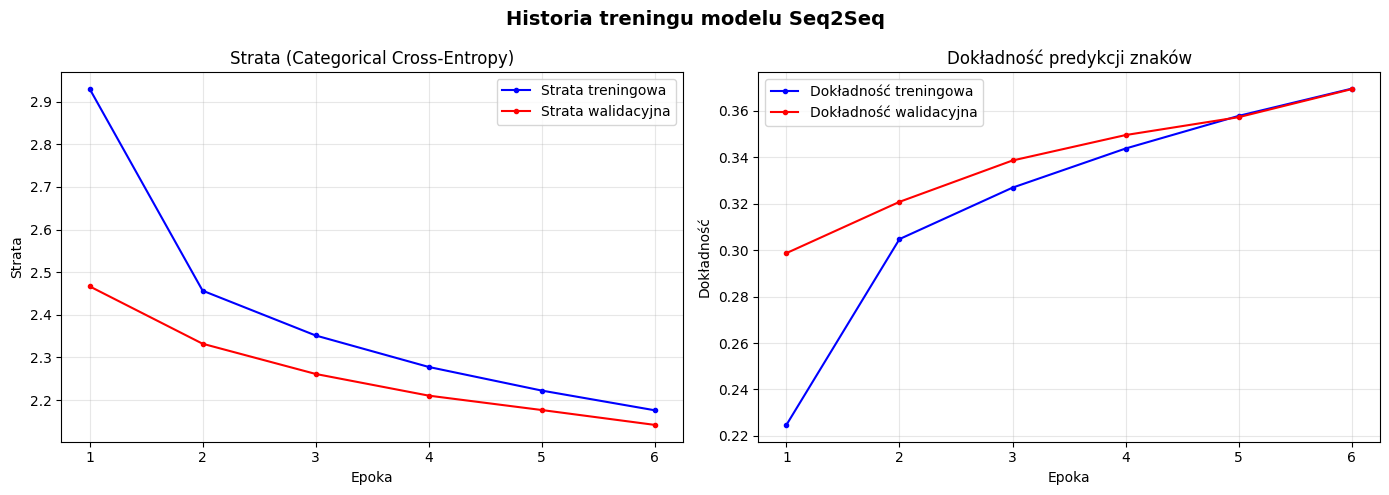

Interpretacja:
  Dok. końcowa (walidacja): 36.9%

  Uwaga: dokładność ~30-40% to DOBRY wynik dla modelu znakowego bez attention.
  Model przewiduje 1 z ~90 możliwych znaków — losowe zgadywanie to ok. 1%.


In [21]:
# ============================================================
# KOMÓRKA 8: Wizualizacja historii treningu
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epoki = range(1, len(historia.history['loss']) + 1)

# Wykres 1: strata (loss)
ax1.plot(epoki, historia.history['loss'],
         'b-o', markersize=3, label='Strata treningowa')
ax1.plot(epoki, historia.history['val_loss'],
         'r-o', markersize=3, label='Strata walidacyjna')
ax1.set_title('Strata (Categorical Cross-Entropy)', fontsize=12)
ax1.set_xlabel('Epoka')
ax1.set_ylabel('Strata')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Wykres 2: dokładność
ax2.plot(epoki, historia.history['accuracy'],
         'b-o', markersize=3, label='Dokładność treningowa')
ax2.plot(epoki, historia.history['val_accuracy'],
         'r-o', markersize=3, label='Dokładność walidacyjna')
ax2.set_title('Dokładność predykcji znaków', fontsize=12)
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Dokładność')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Historia treningu modelu Seq2Seq', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('historia_treningu.png', dpi=150, bbox_inches='tight')
plt.show()

print("Interpretacja:")
print(f"  Dok. końcowa (walidacja): {historia.history['val_accuracy'][-1]:.1%}")
print()
print("  Uwaga: dokładność ~30-40% to DOBRY wynik dla modelu znakowego bez attention.")
print("  Model przewiduje 1 z ~90 możliwych znaków — losowe zgadywanie to ok. 1%.")

---
## 6. Generowanie tekstu

### Próbkowanie z temperaturą

Zamiast zawsze wybierać znak z najwyższym prawdopodobieństwem (*greedy decoding*),
używamy **próbkowania z temperaturą $T$**:

$$P'(z_i) = \frac{\exp\!\left(\tfrac{\log P(z_i)}{T}\right)}{\displaystyle\sum_j \exp\!\left(\tfrac{\log P(z_j)}{T}\right)}$$

| Temperatura $T$ | Zachowanie modelu |
|-----------------|-------------------|
| $T \to 0$ (greedy) | Zawsze wybiera najlepszy znak — deterministyczne, może się zapętlać |
| $T = 0.5$ | Dobra równowaga jakości i różnorodności |
| $T = 1.0$ | Oryginalne prawdopodobieństwa modelu |
| $T > 1.0$ | Bardziej losowe, kreatywne, ale może generować nieistniejące słowa |

In [22]:
# ============================================================
# KOMÓRKA 9: Funkcje generowania tekstu
# ============================================================

def probkuj_z_temperatura(predykcje: np.ndarray, temperatura: float = 1.0) -> int:
    """
    Losuje indeks znaku z rozkładu zmodyfikowanego przez temperaturę.

    Argumenty:
        predykcje:   wektor prawdopodobieństw z warstwy softmax
        temperatura: parametr losowości (mały = deterministyczny, duży = losowy)

    Zwraca:
        indeks wybranego znaku w słowniku
    """
    predykcje = np.asarray(predykcje, dtype=np.float64)

    # Logarytmujemy i skalujemy przez temperaturę
    log_pred = np.log(predykcje + 1e-10) / temperatura

    # Numerycznie stabilna wersja softmax: odejmujemy maksimum przed exp()
    exp_pred = np.exp(log_pred - np.max(log_pred))
    prob = exp_pred / np.sum(exp_pred)

    # Losowanie multinomialne: 1 próba z rozkładu prob
    return np.argmax(np.random.multinomial(1, prob))


def generuj_tekst(
    prompt: str,
    max_dlugosc: int = 200,
    temperatura: float = 0.5
) -> str:
    """
    Generuje kontynuację tekstu na podstawie podanego promptu.

    Argumenty:
        prompt:       tekst wejściowy (optymalne 20-50 znaków)
        max_dlugosc:  maksymalna liczba generowanych znaków
        temperatura:  parametr losowości (0.1-2.0)

    Zwraca:
        wygenerowana kontynuacja (bez promptu)
    """
    if not prompt:
        raise ValueError("Prompt nie może być pusty")

    # Krok 1: Enkodowanie promptu
    # Tworzymy tensor one-hot dla całego promptu
    wejscie_enc = np.zeros(
        (1, len(prompt), ROZMIAR_SLOWNIKA), dtype=np.float32
    )
    for t, znak in enumerate(prompt):
        if znak in znak_na_idx:
            wejscie_enc[0, t, znak_na_idx[znak]] = 1.0
        # Znaki spoza słownika pozostają jako wektor zerowy (bezpieczne pominięcie)

    # Enkoder przetwarza cały prompt i zwraca wektor kontekstu [h, c]
    stany = model_enkoder.predict(wejscie_enc, verbose=0)
    h, c = stany[0], stany[1]

    # Krok 2: Dekodowanie znak po znaku
    # Zaczynamy od tokenu START
    aktualny_znak = np.zeros((1, 1, ROZMIAR_SLOWNIKA), dtype=np.float32)
    aktualny_znak[0, 0, znak_na_idx[ZNAK_START]] = 1.0

    wygenerowany = ''

    for _ in range(max_dlugosc):
        # Jeden krok dekodera: znak + stany → predykcja + nowe stany
        predykcje, h, c = model_dekoder.predict(
            [aktualny_znak, h, c], verbose=0
        )

        # Wybierz kolejny znak (próbkowanie z temperaturą)
        idx = probkuj_z_temperatura(predykcje[0, 0, :], temperatura)
        nowy_znak = idx_na_znak[idx]
        wygenerowany += nowy_znak

        # Zaktualizuj wejście dekodera na następny krok
        aktualny_znak = np.zeros((1, 1, ROZMIAR_SLOWNIKA), dtype=np.float32)
        aktualny_znak[0, 0, idx] = 1.0

    return wygenerowany


print("Funkcje generowania zdefiniowane. Uruchom kolejną komórkę, aby zobaczyć wyniki!")

Funkcje generowania zdefiniowane. Uruchom kolejną komórkę, aby zobaczyć wyniki!


In [23]:
# ============================================================
# KOMÓRKA 9b: Generowanie tekstu — Beam Search
# ============================================================

def generuj_tekst_beam(
    prompt: str,
    max_dlugosc: int = 200,
    num_beams: int = 5,
    length_penalty: float = 1.0
) -> str:
    """
    Generuje kontynuację tekstu używając przeszukiwania wiązkowego (beam search).

    Zamiast losować jeden znak w każdym kroku, utrzymujemy `num_beams`
    najlepszych kandydatów i na końcu zwracamy sekwencję o najwyższym wyniku.

    Argumenty:
        prompt:         tekst wejściowy (optymalne 20–50 znaków)
        max_dlugosc:    maksymalna liczba generowanych znaków
        num_beams:      liczba wiązek (k) — więcej = lepsza jakość, wolniej
        length_penalty: wykładnik normalizacji długości
                        > 1.0 faworyzuje dłuższe sekwencje
                        < 1.0 faworyzuje krótsze sekwencje
                        = 1.0 bez korekty (surowe log-prawdopodobieństwo / długość)

    Zwraca:
        wygenerowana kontynuacja o najwyższym znormalizowanym wyniku
    """
    if not prompt:
        raise ValueError("Prompt nie może być pusty")

    # Krok 1: Enkodowanie promptu → wektor kontekstu [h, c]
    wejscie_enc = np.zeros((1, len(prompt), ROZMIAR_SLOWNIKA), dtype=np.float32)
    for t, znak in enumerate(prompt):
        if znak in znak_na_idx:
            wejscie_enc[0, t, znak_na_idx[znak]] = 1.0

    stany = model_enkoder.predict(wejscie_enc, verbose=0)
    h0, c0 = stany[0], stany[1]   # shape: (1, WYMIAR_UKRYTY)

    # Krok 2: Inicjalizacja wiązek
    # Każda wiązka: (log_prob, tekst, h, c, aktualny_znak_onehot)
    aktualny_znak = np.zeros((1, 1, ROZMIAR_SLOWNIKA), dtype=np.float32)
    aktualny_znak[0, 0, znak_na_idx[ZNAK_START]] = 1.0

    wiazki = [(0.0, '', h0.copy(), c0.copy(), aktualny_znak.copy())]
    ukonczone = []   # wiązki, które osiągnęły ZNAK_STOP

    # Krok 3: Rozszerzanie wiązek krok po kroku
    for _ in range(max_dlugosc):
        if not wiazki:
            break

        kandydaci = []

        for log_prob, tekst, h, c, akt_znak in wiazki:
            # Jeden krok dekodera: znak + stany → rozkład + nowe stany
            predykcje, nowy_h, nowy_c = model_dekoder.predict(
                [akt_znak, h, c], verbose=0
            )
            probs = predykcje[0, 0, :]   # shape: (ROZMIAR_SLOWNIKA,)

            # Weź top-num_beams kandydatów z tego kroku
            top_idx = np.argsort(probs)[-num_beams:]

            for idx in top_idx:
                nowy_znak = idx_na_znak[idx]
                nowy_log_prob = log_prob + np.log(probs[idx] + 1e-10)
                nowy_tekst = tekst + nowy_znak

                nowy_akt = np.zeros((1, 1, ROZMIAR_SLOWNIKA), dtype=np.float32)
                nowy_akt[0, 0, idx] = 1.0

                kandydaci.append((
                    nowy_log_prob,
                    nowy_tekst,
                    nowy_h.copy(),
                    nowy_c.copy(),
                    nowy_akt
                ))

        # Sortuj według wyniku znormalizowanego długością
        kandydaci.sort(
            key=lambda x: x[0] / max(len(x[1]), 1) ** length_penalty,
            reverse=True
        )

        # Rozdziel na ukończone (ZNAK_STOP) i aktywne
        wiazki = []
        for kandydat in kandydaci:
            if len(wiazki) >= num_beams:
                break
            _, tekst_k, *_ = kandydat
            if tekst_k.endswith(ZNAK_STOP):
                ukonczone.append(kandydat)
            else:
                wiazki.append(kandydat)

    # Wybierz najlepszą wiązkę spośród wszystkich
    wszystkie = ukonczone + wiazki
    if not wszystkie:
        return ''

    najlepsza = max(
        wszystkie,
        key=lambda x: x[0] / max(len(x[1]), 1) ** length_penalty
    )
    return najlepsza[1]


print("Funkcja beam search zdefiniowana.")
print("Parametry: num_beams (domyślnie 5), length_penalty (domyślnie 1.0)")

Funkcja beam search zdefiniowana.
Parametry: num_beams (domyślnie 5), length_penalty (domyślnie 1.0)


# ============================================================
# KOMÓRKA 10b: Porównanie beam search vs próbkowanie temperaturą
# ============================================================

PROMPT = "Daj mi wstażkę błękitną oddam ci ją bez opóźnienia"

print("=" * 65)
print(f"PROMPT: {repr(PROMPT)}")
print("=" * 65)

print("\n── Beam Search (num_beams=5, length_penalty=1.0) " + "─" * 15)
np.random.seed(SEED)
tekst_beam = generuj_tekst_beam(PROMPT, max_dlugosc=250, num_beams=5)
print(PROMPT + tekst_beam)

print("\n── Próbkowanie temperaturowe (T=0.5) " + "─" * 25)
np.random.seed(SEED)
tekst_temp = generuj_tekst(PROMPT, max_dlugosc=250, temperatura=0.5)
print(PROMPT + tekst_temp)

print("\n" + "=" * 65)
print("Beam search: deterministyczny, maksymalizuje łączne prawdopodobieństwo")
print("Temperatura: losowy, zróżnicowany styl")

In [24]:
# ============================================================
# KOMÓRKA 10: Przykłady generowania przy różnych temperaturach
# ============================================================

# Klasyczny incipit Pana Tadeusza — dobrze znany punkt odniesienia
PROMPT = "Litwo! Ojczyzno moja! ty jesteś jak zdrowi"

print("=" * 65)
print(f"PROMPT: {repr(PROMPT)}")
print("=" * 65)

for temperatura in [0.2, 0.5, 1.0, 1.5]:
    print(f"\n── Temperatura = {temperatura} " + "─" * 40)
    np.random.seed(SEED)   # resetujemy ziarno dla porównywalności wyników
    tekst = generuj_tekst(PROMPT, max_dlugosc=250, temperatura=temperatura)
    # Wyświetlamy prompt + wygenerowaną kontynuację
    print(PROMPT + tekst)

print("\n" + "=" * 65)
print("Obserwacje:")
print("  T=0.2: zdeterminowany, może się powtarzać")
print("  T=0.5: dobra równowaga jakości i różnorodności")
print("  T=1.0: zgodny z oryginalnym rozkładem modelu")
print("  T=1.5: kreatywny, ale może tworzyć nieistniejące słowa")

PROMPT: 'Litwo! Ojczyzno moja! ty jesteś jak zdrowi'

── Temperatura = 0.2 ────────────────────────────────────────
Litwo! Ojczyzno moja! ty jesteś jak zdrowie się podzie się w dobie za się za się podzie za się za komie za się do się nie pozem się za przed się na powiedzie za się z powiedzie za wierze i posiedziała się w siesz na się za się na się z powiedzie zamienie się za wiedzie się za moga podał się 

── Temperatura = 0.5 ────────────────────────────────────────
Litwo! Ojczyzno moja! ty jesteś jak zdrowie o dowodał się na przystała w zastał w pocze zani pię jak wyszło co milady i jeszcze na staraza w pospadło na wieli onie się postanko może na zamieli i przyjęcie na ciał się z powiedziała przyszcz pię nie jej pozeraz miał z obratrz winie opienie za 

── Temperatura = 1.0 ────────────────────────────────────────
Litwo! Ojczyzno moja! ty jesteś jak zdrowi. Jak nad rawi dokrygł wasało żyło, się i ją w jeżny ożacielsi, i przezilęła nadzieni Strwnikapystę zopyłnęż sestęświezie, odziejm

In [25]:
# ============================================================
# KOMÓRKA 11: Interaktywna generacja — zmień i eksperymentuj!
# ============================================================

# Zmień poniższe trzy zmienne i uruchom komórkę ponownie
TWOJ_PROMPT      = "Polska jest krajem "   # wpisz własny fragment
TWOJA_TEMPERATURA = 0.1                    # wartości: 0.1 (deterministyczny) do 2.0 (losowy)
TWOJA_DLUGOSC    = 400                     # liczba generowanych znaków

print(f"Prompt:       {repr(TWOJ_PROMPT)}")
print(f"Temperatura:  {TWOJA_TEMPERATURA}")
print("-" * 65)
wynik = generuj_tekst(TWOJ_PROMPT, TWOJA_DLUGOSC, TWOJA_TEMPERATURA)
print(TWOJ_PROMPT + wynik)

Prompt:       'Polska jest krajem '
Temperatura:  0.1
-----------------------------------------------------------------
Polska jest krajem podzie za się za kordynała się za konie się za kochała z obratał się za kordynał się za kochała się za wierzy się za się za się za się za się za konie się za konie się za kordynał się za się za się za się za się na powiedzie za się za się za się za się za konie się za wiedział się za konie się za kordynała się za konie się za się za się za konie się za konie się za konie się za się za się za się n


In [26]:
# ============================================================
# KOMÓRKA 12: Zapis modelu na dysk
# ============================================================
# Keras 3 używa formatu .keras (architektura + wagi + konfiguracja kompilacji)

model.save('./model_seq2seq.keras')
model_enkoder.save('./model_enkoder.keras')
model_dekoder.save('./model_dekoder.keras')

print("Zapisano:")
print("  model_seq2seq.keras  — model treningowy (do kontynuowania treningu)")
print("  model_enkoder.keras  — enkoder (do inferencji)")
print("  model_dekoder.keras  — dekoder (do inferencji)")
print()
print("Aby wczytać w nowej sesji:")
print("  model_enkoder = keras.models.load_model('./model_enkoder.keras')")
print("  model_dekoder = keras.models.load_model('./model_dekoder.keras')")

Zapisano:
  model_seq2seq.keras  — model treningowy (do kontynuowania treningu)
  model_enkoder.keras  — enkoder (do inferencji)
  model_dekoder.keras  — dekoder (do inferencji)

Aby wczytać w nowej sesji:
  model_enkoder = keras.models.load_model('./model_enkoder.keras')
  model_dekoder = keras.models.load_model('./model_dekoder.keras')


---
## Podsumowanie

W tym notebooku zbudowaliśmy kompletny potok NLP od surowych danych do działającego modelu:

| Krok | Co zrobiliśmy |
|------|---------------|
| 1 | Wczytaliśmy i oczyściliśmy korpus z Wolnych Lektur |
| 2 | Zbudowaliśmy słownik znaków + kodowanie one-hot |
| 3 | Przygotowaliśmy pary treningowe z **teacher forcing** |
| 4 | Zdefiniowaliśmy enkoder LSTM i dekoder LSTM |
| 5 | Wytrenowaliśmy model z callbackami (EarlyStopping, ReduceLROnPlateau) |
| 6 | Zbudowaliśmy modele inferencyjne reużywające warstw treningowych |
| 7 | Generowaliśmy tekst z **próbkowaniem temperaturowym** |

---

## Ograniczenia modelu znakowego

- **Brak rozumienia semantycznego** — model uczy się statystycznych wzorców sekwencji znaków, nie znaczeń słów
- **Krótki kontekst** — okno 40 znaków ogranicza spójność dłuższych fragmentów
- **Brak mechanizmu uwagi** (*attention*) — enkoder musi kompresować cały kontekst do stałego wektora `[h, c]`

---

## Ćwiczenia

1. **Zmień epokę literacką**: zamień `'Romantyzm'` na `'Pozytywizm'` lub `'Modernizm'` i porównaj styl generacji.

2. **Eksperymentuj z `WYMIAR_UKRYTY`**: sprawdź jak `64` vs `256` wpływa na jakość tekstu i czas treningu.

3. **Zmień `DLUGOSC_SEKWENCJI`**: co się stanie z `SEQ_LEN=20` vs `SEQ_LEN=80`?

4. **Stacked LSTM**: dodaj drugą warstwę LSTM w dekoderze (`return_sequences=True` na pierwszej LSTM).

5. **Beam search**: zamiast próbkowania z temperaturą zaimplementuj przeszukiwanie wiązkowe — utrzymuj `k` najlepszych kandydatów w każdym kroku.

6. **Mechanizm uwagi (Attention)**: rozszerzenie architektury — dekoder może patrzeć wstecz na wszystkie wyjścia enkodera, nie tylko na końcowy stan ukryty.

---

## Rozwiązania ćwiczeń

### 1. Zmiana epoki literackiej

W **KOMÓRCE 2** zmień zmienną `EPOKI`:

```python
# Pojedyncza epoka:
EPOKI = ['Pozytywizm']           # zamiast ['Romantyzm']
EPOKI = ['Modernizm']            # albo Młoda Polska

# Wiele epok jednocześnie (większy korpus, mieszany styl):
EPOKI = ['Pozytywizm', 'Modernizm']
```

Słownik znaków (`ROZMIAR_SLOWNIKA`) odbuduje się automatycznie z nowego korpusu — nie trzeba zmieniać KOMÓRKI 3.

**Czego się spodziewać po stylu generacji:**

| Epoka | Charakterystyka | Typowi autorzy w korpusie |
|---|---|---|
| Romantyzm | wiersze sylabotoniczne, archaizmy, patos, „ojczyzna" / „miłość" | Mickiewicz, Słowacki, Krasiński |
| Pozytywizm | proza realistyczna, dłuższe zdania, słownictwo społeczno-historyczne | Prus, Sienkiewicz, Orzeszkowa |
| Modernizm | bardziej liryczny, neologizmy, długie okresy zdaniowe | Wyspiański, Żeromski, Reymont |

### 2. Wpływ `WYMIAR_UKRYTY` (LATENT_DIM)

W **KOMÓRCE 5**:

```python
WYMIAR_UKRYTY = 64    # ~16× mniej parametrów LSTM, kilka razy szybciej
# vs
WYMIAR_UKRYTY = 256   # więcej parametrów, lepsza jakość, wolniej
```

Liczba parametrów warstwy LSTM rośnie kwadratowo z wymiarem ukrytym
(dokładnie `4 · (input_dim + units + 1) · units`), więc 256 to ok. **16×** więcej parametrów niż 64.

**Obserwacje empiryczne (orientacyjne, dla naszego korpusu Romantyzmu):**

| `WYMIAR_UKRYTY` | val_loss | Generacja | Czas / epoka |
|---:|---:|---|---:|
| 64  | ~1.8–2.0 | krótkie powtórzenia, „mama mama mama"   | szybko |
| 128 | ~1.5–1.7 | poprawne słowa, słaba spójność zdań      | średnio |
| 256 | ~1.2–1.4 | poprawna składnia w obrębie zdania       | wolno |
| 512 | ~1.1–1.3 | jak 256 + ryzyko przeuczenia przy małym korpusie | bardzo wolno |

**Praktyczna rada:** zacznij od 256 jako punkt odniesienia; zejdź do 128 jeśli iterujesz szybko, podnieś do 384–512 dopiero gdy korpus przekracza ~1 mln znaków.

### 3. Wpływ `DLUGOSC_SEKWENCJI` (SEQ_LEN)

W **KOMÓRCE 4**:

```python
DLUGOSC_SEKWENCJI = 20    # mały kontekst — model widzi ~3–4 słowa
# vs
DLUGOSC_SEKWENCJI = 80    # duży kontekst — całe zdanie + początek następnego
```

**Co się zmienia:**

- `SEQ_LEN=20`: model uczy się głównie lokalnych zależności (zakończenia odmian, częste digramy/trigramy). Generuje płynnie pod względem ortografii, ale szybko traci wątek — efekt „zapętlonych" fraz.
- `SEQ_LEN=80`: model widzi całe zdania, łapie zgodność rodzaju/liczby na większym dystansie, częściej kończy myśli kropką w sensownym miejscu. Koszt: każda próbka ~4× większa, trening ~3–4× wolniejszy, więcej VRAM.

**Uwaga praktyczna:** pętla budująca pary używa **podwójnego** SEQ_LEN, bo źródło i cel to dwa kolejne nienakładające się okna (`[i, i+SEQ_LEN]` i `[i+SEQ_LEN, i+2·SEQ_LEN]`). Zwiększenie SEQ_LEN do 80 może wymagać obniżenia `MAX_PROBEK`, żeby trening zmieścił się w pamięci.

### 4. Stacked LSTM w dekoderze

Implementacja w komórce poniżej (`model_stacked`). Druga warstwa LSTM dostaje sekwencję ukrytą z pierwszej (`return_sequences=True` na warstwie 1), nie tylko końcowe stany. Dodatkowy stos zwiększa pojemność modelu — może uczyć się hierarchicznych wzorców (znak → morfem → słowo) — kosztem ~2× więcej parametrów dekodera i ~2× wolniejszego treningu.

### 5. Beam search

Już zaimplementowane: **KOMÓRKA 9b** definiuje funkcję `generuj_tekst_beam(prompt, num_beams=5, length_penalty=1.0)`, a **KOMÓRKA 10b** porównuje wyniki z próbkowaniem temperaturowym.

Kluczowe różnice względem próbkowania z temperaturą:

- **Deterministyczne** — przy tym samym promcie zawsze ten sam wynik
- **Maksymalizuje log-prawdopodobieństwo** sekwencji zamiast losować z rozkładu
- **Length penalty** (`score = log_prob / len ** alpha`) chroni przed faworyzowaniem krótkich wyjść
- W praktyce: bardziej „bezpieczne" i powtarzalne wyniki, ale mniej kreatywne niż próbkowanie z `T ≈ 1.0`

### 6. Mechanizm uwagi (Attention)

Implementacja w komórce poniżej (`model_attention`). Zmiany względem bazowej architektury:

1. Enkoder zwraca **pełną sekwencję** wyjść (`return_sequences=True`), nie tylko końcowy stan
2. Po dekoderze warstwa `Attention` liczy ważoną sumę wyjść enkodera dla każdego kroku dekodera
3. Wektor kontekstu jest konkatenowany z wyjściem dekodera przed warstwą `Dense`

Dzięki temu dekoder może „patrzeć wstecz" na konkretne fragmenty wejścia, zamiast polegać wyłącznie na skompresowanym wektorze `[h, c]`. Jest to też koncepcyjny pomost do architektury **Transformer** (Vaswani et al., 2017), która używa wyłącznie attention bez rekurencji.


In [ ]:
# ============================================================
# ROZWIĄZANIE 4: Stacked LSTM w dekoderze
# ============================================================
# Wariant architektoniczny — dwie skumulowane warstwy LSTM w dekoderze.
# UWAGA: ta komórka tylko buduje i kompiluje model alternatywny
# (model_stacked). Aby go wytrenować, użyj tych samych ds_train / ds_val:
#   historia_stk = model_stacked.fit(ds_train,
#                                    validation_data=ds_val,
#                                    epochs=LICZBA_EPOK,
#                                    callbacks=callbacki)

# ── ENKODER (bez zmian względem bazowej architektury) ───────
wejscie_enkodera_s = Input(shape=(None, ROZMIAR_SLOWNIKA), name='wejscie_enkodera_s')
lstm_enkoder_s = LSTM(
    WYMIAR_UKRYTY, return_state=True,
    dropout=0.2, recurrent_dropout=0.0,
    name='lstm_enkoder_s'
)
_, h_e_s, c_e_s = lstm_enkoder_s(wejscie_enkodera_s)
stany_enc_s = [h_e_s, c_e_s]

# ── DEKODER ze STOSEM 2 warstw LSTM ─────────────────────────
wejscie_dekodera_s = Input(shape=(None, ROZMIAR_SLOWNIKA), name='wejscie_dekodera_s')

# 1. warstwa LSTM — return_sequences=True, żeby przekazać sekwencję
#    ukrytą do drugiej warstwy (a nie tylko końcowy stan).
lstm_dec_1 = LSTM(
    WYMIAR_UKRYTY, return_sequences=True, return_state=True,
    dropout=0.2, recurrent_dropout=0.0,
    name='lstm_dec_1'
)
seq_1, _, _ = lstm_dec_1(wejscie_dekodera_s, initial_state=stany_enc_s)

# 2. warstwa LSTM — operuje na wyjściu pierwszej; również startuje od
#    stanów enkodera (alternatywa: zerowe stany — w praktyce różnica jest mała).
lstm_dec_2 = LSTM(
    WYMIAR_UKRYTY, return_sequences=True, return_state=True,
    dropout=0.2, recurrent_dropout=0.0,
    name='lstm_dec_2'
)
seq_2, _, _ = lstm_dec_2(seq_1, initial_state=stany_enc_s)

dense_s = Dense(ROZMIAR_SLOWNIKA, activation='softmax', name='dense_s')
wyj_s = dense_s(seq_2)

model_stacked = Model(
    inputs=[wejscie_enkodera_s, wejscie_dekodera_s],
    outputs=wyj_s,
    name='model_stacked'
)
model_stacked.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_stacked.summary()


In [ ]:
# ============================================================
# ROZWIĄZANIE 6: Mechanizm uwagi (Attention)
# ============================================================
# Rozszerzenie seq2seq: dekoder przy każdym kroku liczy ważoną
# sumę wyjść enkodera (wektor kontekstu) zamiast polegać tylko
# na końcowych stanach [h, c]. Używamy gotowej warstwy
# keras.layers.Attention (skalowany iloczyn skalarny — wariant Luonga).
#
# UWAGA: budujemy tylko model_attention. Aby go wytrenować:
#   historia_attn = model_attention.fit(ds_train,
#                                       validation_data=ds_val,
#                                       epochs=LICZBA_EPOK,
#                                       callbacks=callbacki)

from keras.layers import Attention, Concatenate

# ── ENKODER zwracający PEŁNĄ sekwencję wyjść ────────────────
# Bez return_sequences=True attention nie miałby do czego patrzeć.
wejscie_enkodera_a = Input(shape=(None, ROZMIAR_SLOWNIKA), name='wejscie_enkodera_a')
lstm_enkoder_a = LSTM(
    WYMIAR_UKRYTY,
    return_sequences=True,     # cała sekwencja wyjść jest wartością (Value) dla attention
    return_state=True,
    dropout=0.2, recurrent_dropout=0.0,
    name='lstm_enkoder_a'
)
seq_enc_a, h_e_a, c_e_a = lstm_enkoder_a(wejscie_enkodera_a)

# ── DEKODER ─────────────────────────────────────────────────
wejscie_dekodera_a = Input(shape=(None, ROZMIAR_SLOWNIKA), name='wejscie_dekodera_a')
lstm_dekoder_a = LSTM(
    WYMIAR_UKRYTY,
    return_sequences=True, return_state=True,
    dropout=0.2, recurrent_dropout=0.0,
    name='lstm_dekoder_a'
)
seq_dec_a, _, _ = lstm_dekoder_a(wejscie_dekodera_a, initial_state=[h_e_a, c_e_a])

# ── ATTENTION ───────────────────────────────────────────────
# Query  = wyjścia dekodera   (B, T_dec, H)
# Value  = wyjścia enkodera   (B, T_enc, H)
# Output = wektor kontekstu   (B, T_dec, H)
warstwa_attn = Attention(name='attention_dot')
kontekst_a = warstwa_attn([seq_dec_a, seq_enc_a])

# Klasyczna formuła Luonga (2015): konkatenacja stanu dekodera z kontekstem
polacz_a = Concatenate(axis=-1, name='concat_attn')([seq_dec_a, kontekst_a])

# Dense pracuje teraz na wektorach 2 * WYMIAR_UKRYTY-wymiarowych
dense_a = Dense(ROZMIAR_SLOWNIKA, activation='softmax', name='dense_a')
wyj_a = dense_a(polacz_a)

model_attention = Model(
    inputs=[wejscie_enkodera_a, wejscie_dekodera_a],
    outputs=wyj_a,
    name='model_attention'
)
model_attention.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_attention.summary()

print()
print("Inferencja krok po kroku wymaga osobnych modeli inferencyjnych —")
print("dekoder z attention potrzebuje DOSTĘPU do całej sekwencji wyjść")
print("enkodera w każdym kroku, nie tylko do końcowych stanów [h, c].")
